# Smart MCQ Solver Challenge | Pre-trained Transformer (DeBERTa-v3)

The objective of this notebook is to fine-tune a pre-trained Transformer model (`microsoft/deberta-v3-base`) to identify and rank the top three most likely correct answers for multiple-choice questions (MCQs).

---

## Overview

Each question in the dataset consists of a **prompt** and five answer choices: **A, B, C, D,** and **E**.

The model processes each question by pairing the prompt with each option choice `(prompt, option_X)` and predicting a scalar score for each choice.

The model generates **top three predicted choices in ranked order**.

---

## Evaluation Metric

Performance is measured using **Mean Average Precision at 3 (MAP@3)**.

For a single question, **Average Precision at 3 (AP@3)** is defined as:

$$
AP@3 = \begin{cases} \frac{1}{r}, & \text{if correct answer is at rank } r \le 3 \\ 0, & \text{otherwise} \end{cases}
$$

where $r$ is the 1-based rank position of the correct answer.

The final score is the mean AP@3 across all $N$ questions:

$$
MAP@3 = \frac{1}{N} \sum_{i=1}^{N} AP_i@3
$$

Top-1 Accuracy and Macro F1-score are also recorded for comparison.

---

## Dataset Structure

| Column | Description |
|---|---|
| `id` | Unique identifier for each question |
| `prompt` | Question text / problem statement |
| `A`, `B`, `C`, `D`, `E` | Five answer choices |
| `answer` | Ground-truth correct option letter (`A`-`E`) |

In [2]:
!pip uninstall -y transformers -q
!pip install transformers==5.12.1 --no-cache-dir -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 177.9 MB/s eta 0:00:00


In [3]:
!pip install -q \
    tokenizers==0.22.2 \
    accelerate==1.14.0 \
    sentencepiece==0.2.1 \
    safetensors==0.8.0 \
    wandb==0.28.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have num

## 1. Imports & Setup

Essential Python packages, PyTorch modules, and Hugging Face Transformers libraries are imported. Fixed random seeds (`42`) are configured across NumPy, Python, and PyTorch for reproducibility.

In [4]:
import os
import re
import gc
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_cosine_schedule_with_warmup,
)

# set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

MODEL_NAME = "microsoft/deberta-v3-base"
LABELS = ["A", "B", "C", "D", "E"]
NUM_LABELS = len(LABELS)

plt.style.use("ggplot")

Using device: cuda


## 2. Weights & Biases (W&B) Setup

Weights & Biases (W&B) is initialized to log training loss, validation accuracy, Macro F1-score, and MAP@3 metrics.

In [5]:
import wandb
from kaggle_secrets import UserSecretsClient

wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))

WANDB_PROJECT = "24f2001637-t22026"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


## 3. Helper Functions

Utility functions defined for data cleaning, label mapping, evaluation metrics (`AP@3`, `MAP@3`), and submission CSV formatting:

- **`clean_text`**: Normalizes text and removes special characters.
- **`label_to_idx` / `idx_to_label`**: Maps letter options (`A`-`E`) to numeric indices (`0`-`4`) and vice versa.
- **`average_precision_at_k` / `map_at_3`**: Computes AP@3 and MAP@3 evaluation metrics.
- **`compute_metrics`**: Calculates Top-1 Accuracy, Macro F1, and MAP@3.
- **`format_submission`**: Formats output predictions into `submission.csv`.

In [6]:
# clean text
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s.,!?;:()\-\'"]+', ' ', text)
    return text.strip()


def label_to_idx(label):
    return ord(label.upper()) - ord('A')


def idx_to_label(idx):
    return chr(ord('A') + idx)


# calculate AP@3
def average_precision_at_k(predicted, actual, k=3):
    predicted = predicted[:k]
    if actual not in predicted:
        return 0.0
    rank = predicted.index(actual) + 1
    return 1.0 / rank


def map_at_3(predictions, actuals):
    scores = [average_precision_at_k(pred, actual, k=3) for pred, actual in zip(predictions, actuals)]
    return float(np.mean(scores))


# compute all metrics
def compute_metrics(true_labels, top3_preds):
    top1 = [p[0] for p in top3_preds]
    acc = accuracy_score(true_labels, top1)
    f1 = f1_score(true_labels, top1, average="macro")
    map3 = map_at_3(top3_preds, true_labels)
    return {
        "accuracy": float(acc),
        "f1_macro": float(f1),
        "map@3": map3
    }


# save predictions
def format_submission(ids, predictions, output_path="submission.csv"):
    formatted_preds = []
    for pred in predictions:
        formatted_preds.append(" ".join(pred))
        
    sub = pd.DataFrame({
        "id": ids,
        "Prediction": formatted_preds
    })
    sub.to_csv(output_path, index=False)
    print(f"Saved submission -> {output_path} ({len(sub)} rows)")
    return sub

## 4. Load Data

Training (`train.csv`) and test (`test.csv`) sets are loaded. Missing option values are replaced with empty strings.

In [7]:
# load train and test data
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

# fill missing option values
for df in [train_df, test_df]:
    for col in LABELS:
        df[col] = df[col].fillna("").astype(str)

print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")
print("\nColumn types:")
print(train_df.dtypes)

train_df.head(3)

Train shape: (2000, 8) | Test shape: (500, 7)

Column types:
id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


## 5. Exploratory Data Analysis (EDA)

Key dataset characteristics analyzed:
- Target label balance across choices `A`-`E`.
- Prompt and option word length distributions.
- Presence of duplicate question prompts.

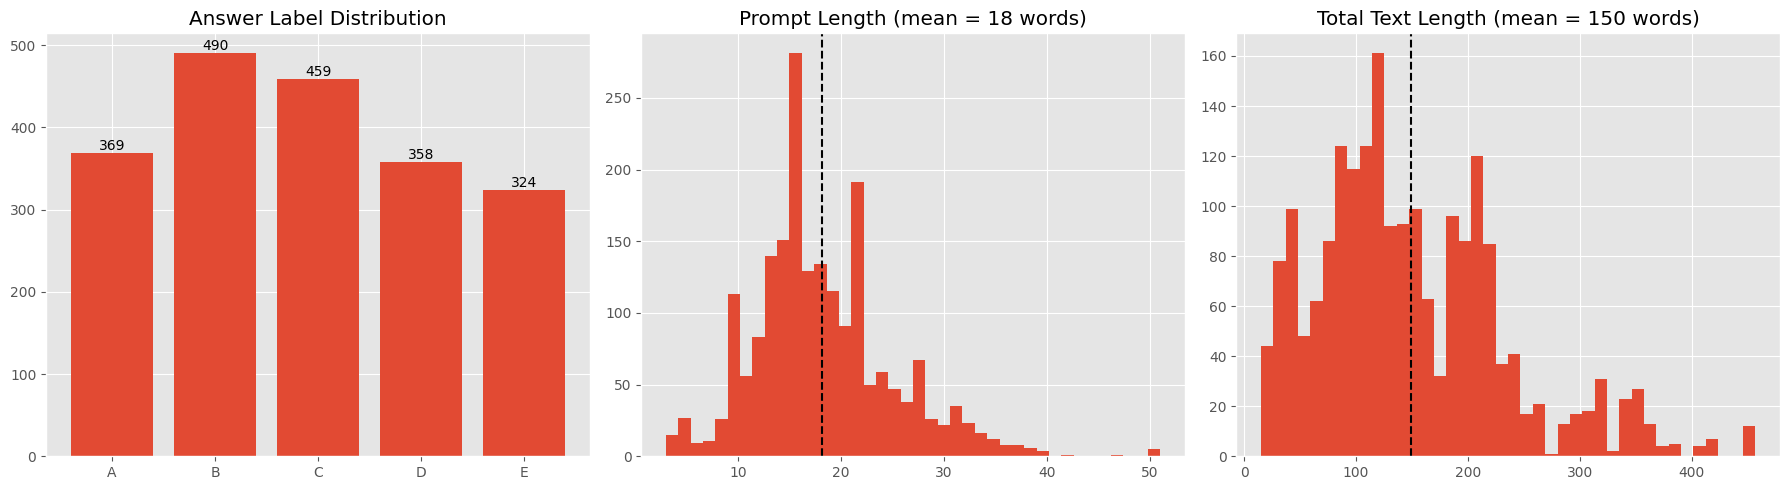


Duplicate prompts in train: 454


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Answer distribution
answer_counts = train_df["answer"].value_counts().sort_index()
axes[0].bar(answer_counts.index, answer_counts.values)
axes[0].set_title("Answer Label Distribution")
for i, v in enumerate(answer_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# 2. Prompt length in words
prompt_len = train_df["prompt"].str.split().str.len()
axes[1].hist(prompt_len, bins=40)
axes[1].axvline(prompt_len.mean(), linestyle="--", color="black")
axes[1].set_title(f"Prompt Length (mean = {prompt_len.mean():.0f} words)")

# 3. Total text length
option_total = sum(train_df[label].str.split().str.len() for label in LABELS)
total_len = prompt_len + option_total
axes[2].hist(total_len, bins=40)
axes[2].axvline(total_len.mean(), linestyle="--", color="black")
axes[2].set_title(f"Total Text Length (mean = {total_len.mean():.0f} words)")

plt.tight_layout()
plt.show()

print(f"\nDuplicate prompts in train: {train_df.duplicated('prompt', keep=False).sum()}")

## 6. Preprocessing & Train/Validation Split

Data partitioning:
1. **Formatting**: Questions are converted into 5 prompt-option sequence pairs.
2. **Train/Validation Split**: Data is divided into 90% training (`train_sub`) and 10% validation (`val_sub`).

In [9]:
# split train/val
train_sub, val_sub = train_test_split(train_df, test_size=0.1, random_state=42)
train_sub = train_sub.reset_index(drop=True)
val_sub = val_sub.reset_index(drop=True)

print(f"Train split: {len(train_sub)} | Validation split: {len(val_sub)}")

val_true = [str(r['answer']) for _, r in val_sub.iterrows()]
all_run_results = []

Train split: 1800 | Validation split: 200


## 7. Tokenizer & Dataset

The DeBERTa-v3 tokenizer is loaded. `MCQDataset` converts each question into 5 tokenized `(prompt, option)` pairs of shape `(5, max_len)`.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__} | vocab size = {tokenizer.vocab_size:,}")


class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, has_answer=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.has_answer = has_answer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        prompt = str(row['prompt'])
        options = [str(row[l]) for l in LABELS]

        enc = self.tokenizer(
            [prompt] * NUM_LABELS,
            options,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v for k, v in enc.items()}

        if self.has_answer:
            item["label"] = torch.tensor(label_to_idx(row['answer']), dtype=torch.long)
        return item

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer: DebertaV2Tokenizer | vocab size = 128,000


## 8. Model Architecture: DeBERTa-v3 Multiple-Choice

The architecture uses a pre-trained DeBERTa-v3 backbone with a linear classification head. Each `(prompt, option)` pair is encoded, and the `[CLS]` token representation is mapped to a scalar score per choice.

In [ ]:
class DeBERTaMCQ(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name).to(torch.float32)
        hidden = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.scorer = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        b, n, s = input_ids.shape
        input_ids = input_ids.view(b * n, s)
        attention_mask = attention_mask.view(b * n, s)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.view(b * n, s)

        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        scores = self.scorer(cls).view(b, n)
        return scores

## 9. Training & Evaluation Utilities

Functions to manage model training, mixed-precision batching, validation evaluation, checkpoint saving, and logit prediction.

In [12]:
def collate(batch):
    out = {}
    for key in ("input_ids", "attention_mask", "token_type_ids"):
        if key in batch[0]:
            out[key] = torch.stack([b[key] for b in batch], dim=0)
    if "label" in batch[0]:
        out["label"] = torch.stack([b["label"] for b in batch], dim=0)
    return out


@torch.no_grad()
def predict_logits(model, loader):
    model.eval()
    all_logits = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            logits = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch.get("token_type_ids"),
            )
        all_logits.append(logits.float().cpu().numpy())
    return np.concatenate(all_logits, axis=0)


def logits_to_top3(logits):
    order = np.argsort(-logits, axis=1)[:, :3]
    top3_preds = []
    for row in order:
        top3_preds.append([idx_to_label(int(j)) for j in row])
    return top3_preds


def train_model(run_name, train_df, val_df, lr, epochs, max_len,
                batch_size=2, accum_steps=8, weight_decay=0.01, warmup_ratio=0.1, dropout=0.1):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    config = dict(
        model=MODEL_NAME, lr=lr, epochs=epochs, max_len=max_len,
        batch_size=batch_size, accum_steps=accum_steps,
        weight_decay=weight_decay, warmup_ratio=warmup_ratio, dropout=dropout,
    )
    run = wandb.init(project=WANDB_PROJECT, name=run_name, job_type="train", config=config)

    train_ds = MCQDataset(train_df, tokenizer, max_len=max_len, has_answer=True)
    val_ds = MCQDataset(val_df, tokenizer, max_len=max_len, has_answer=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

    model = DeBERTaMCQ(MODEL_NAME, dropout=dropout).float().to(DEVICE)
    model.backbone.gradient_checkpointing_enable()

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = math.ceil(len(train_loader) / accum_steps) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        warmup_steps,
        total_steps,
    )

    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    print(f"\n=== Run: {run_name} ===")
    print(f"  params       = {sum(p.numel() for p in model.parameters()):,}")
    print(f"  total_steps  = {total_steps} (warmup {warmup_steps})")
    print(f"  effective_bs = {batch_size * accum_steps}")

    best_map3 = 0.0
    best_state = None
    history = []

    try:
        for epoch in range(1, epochs + 1):

            # training
            model.train()
            optimizer.zero_grad()

            running_loss = 0.0
            running_correct = 0
            running_n = 0

            for step, batch in enumerate(train_loader, 1):
                batch = {k: v.to(DEVICE) for k, v in batch.items()}

                with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
                    logits = model(
                        input_ids=batch["input_ids"],
                        attention_mask=batch["attention_mask"],
                        token_type_ids=batch.get("token_type_ids"),
                    )
                    loss = criterion(logits, batch["label"]) / accum_steps

                scaler.scale(loss).backward()

                running_loss += loss.item() * accum_steps * batch["label"].size(0)
                running_correct += (logits.argmax(1) == batch["label"]).sum().item()
                running_n += batch["label"].size(0)

                if step % accum_steps == 0 or step == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()

            train_loss = running_loss / running_n
            train_acc = running_correct / running_n

            # validation
            val_logits = predict_logits(model, val_loader)
            val_top3 = logits_to_top3(val_logits)

            metrics = compute_metrics(val_true, val_top3)
            metrics["train_loss"] = train_loss
            metrics["train_acc"] = train_acc
            metrics["epoch"] = epoch

            wandb.log(
                {f"train/{k}": v for k, v in metrics.items()
                 if k in ("train_loss", "train_acc")},
                step=epoch,
            )

            wandb.log(
                {f"val/{k}": v for k, v in metrics.items()
                 if k in ("accuracy", "f1_macro", "map@3")},
                step=epoch,
            )

            print(
                f"  epoch {epoch:2d}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_acc={metrics['accuracy']:.4f} "
                f"val_f1={metrics['f1_macro']:.4f} "
                f"val_map3={metrics['map@3']:.4f}"
            )

            history.append(metrics)

            # save best model
            if metrics["map@3"] > best_map3:
                best_map3 = metrics["map@3"]
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }

        best_metrics = max(history, key=lambda h: h["map@3"])

        wandb.run.summary["best_val_accuracy"] = best_metrics["accuracy"]
        wandb.run.summary["best_val_f1_macro"] = best_metrics["f1_macro"]
        wandb.run.summary["best_val_map@3"] = best_metrics["map@3"]

    finally:
        wandb.finish()

        # clear GPU memory
        del model, optimizer, scheduler
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return best_metrics, best_state, history

## 10. Model Training

The DeBERTa-v3-base model is fine-tuned using a learning rate of `1e-5`, `7` epochs, and a sequence length of `320` (`max_len`).

In [13]:
# train model
best_metrics, best_state, history = train_model(
    run_name="deberta-v3-base_lr1e-5_ep5_ml320",
    train_df=train_sub, val_df=val_sub,
    lr=1e-5, epochs=7, max_len=320,
)
best_max_len = 320
all_run_results.append({"run": "deberta-v3-base_lr1e-5_ep5_ml320", **best_metrics})
print(f"\nRun best -> acc={best_metrics['accuracy']:.4f} | f1={best_metrics['f1_macro']:.4f} | map@3={best_metrics['map@3']:.4f}")

wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260712_035820-x3t99vii
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run deberta-v3-base_lr1e-5_ep5_ml320
wandb: ⭐️ View project at https://wandb.ai/DL-GenAI-24f2001637/24f2001637-t22026
wandb: 🚀 View run at https://wandb.ai/DL-GenAI-24f2001637/24f2001637-t22026/runs/x3t99vii


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Run: deberta-v3-base_lr1e-5_ep5_ml320 ===
  params       = 183,832,321
  total_steps  = 791 (warmup 79)
  effective_bs = 16
  epoch  1/7 | train_loss=1.5965 train_acc=0.2322 | val_acc=0.5700 val_f1=0.5689 val_map3=0.7175
  epoch  2/7 | train_loss=0.8311 train_acc=0.6833 | val_acc=0.9550 val_f1=0.9550 val_map3=0.9742
  epoch  3/7 | train_loss=0.2825 train_acc=0.8994 | val_acc=1.0000 val_f1=1.0000 val_map3=1.0000
  epoch  4/7 | train_loss=0.1351 train_acc=0.9517 | val_acc=1.0000 val_f1=1.0000 val_map3=1.0000
  epoch  5/7 | train_loss=0.0746 train_acc=0.9728 | val_acc=0.9850 val_f1=0.9852 val_map3=0.9850
  epoch  6/7 | train_loss=0.0514 train_acc=0.9794 | val_acc=0.9900 val_f1=0.9902 val_map3=0.9917


wandb: updating run metadata


  epoch  7/7 | train_loss=0.0458 train_acc=0.9844 | val_acc=0.9900 val_f1=0.9902 val_map3=0.9933


wandb: 
wandb: Run history:
wandb:  train/train_acc ▁▅▇████
wandb: train/train_loss █▅▂▁▁▁▁
wandb:     val/accuracy ▁▇█████
wandb:     val/f1_macro ▁▇█████
wandb:        val/map@3 ▁▇█████
wandb: 
wandb: Run summary:
wandb: best_val_accuracy 1
wandb: best_val_f1_macro 1
wandb:    best_val_map@3 1
wandb:   train/train_acc 0.98444
wandb:  train/train_loss 0.04577
wandb:      val/accuracy 0.99
wandb:      val/f1_macro 0.9902
wandb:         val/map@3 0.99333
wandb: 
wandb: 🚀 View run deberta-v3-base_lr1e-5_ep5_ml320 at: https://wandb.ai/DL-GenAI-24f2001637/24f2001637-t22026/runs/x3t99vii
wandb: ⭐️ View project at: https://wandb.ai/DL-GenAI-24f2001637/24f2001637-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260712_035820-x3t99vii/logs



Run best -> acc=1.0000 | f1=1.0000 | map@3=1.0000


## 11. Model Evaluation

Validation performance metrics (Accuracy, Macro F1-score, and MAP@3) are reported and plotted.

                                  accuracy  f1_macro  map@3  train_loss  \
run                                                                       
deberta-v3-base_lr1e-5_ep5_ml320       1.0       1.0    1.0      0.2825   

                                  train_acc  epoch  
run                                                 
deberta-v3-base_lr1e-5_ep5_ml320     0.8994      3  


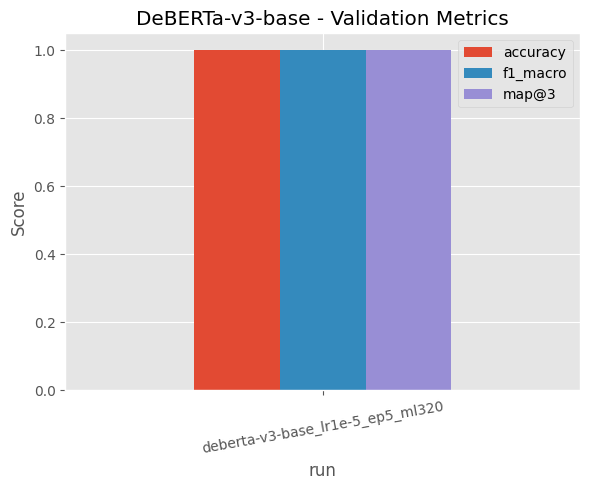

In [14]:
# plot metrics
comparison_df = pd.DataFrame(all_run_results).set_index("run")
print(comparison_df.round(4))

comparison_df[["accuracy", "f1_macro", "map@3"]].plot(kind="bar", figsize=(6, 5), legend=True)
plt.title("DeBERTa-v3-base - Validation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 12. Load Model Checkpoint

The saved checkpoint with the highest validation MAP@3 score is loaded for test inference.

In [15]:
# load checkpoint
best_model = DeBERTaMCQ(MODEL_NAME).to(DEVICE)
best_model.load_state_dict(best_state)
best_model.eval()

print(f"Loaded checkpoint (max_len={best_max_len}) -> "
      f"acc={best_metrics['accuracy']:.4f} | f1={best_metrics['f1_macro']:.4f} | map@3={best_metrics['map@3']:.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint (max_len=320) -> acc=1.0000 | f1=1.0000 | map@3=1.0000


## 13. Test Set Predictions

The fine-tuned model evaluates `test.csv` and outputs top-3 ranked predictions per question.

In [16]:
# predict on test set
print("Generating predictions on the test set using the trained DeBERTa-v3 model...")

test_ds = MCQDataset(test_df, tokenizer, max_len=best_max_len, has_answer=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, collate_fn=collate)

test_logits = predict_logits(best_model, test_loader)
test_top3 = logits_to_top3(test_logits)

print(f"\nSample predictions (first 5):")
for i in range(5):
    print(f"  id={test_df.iloc[i]['id']}  ->  {' '.join(test_top3[i])}")

Generating predictions on the test set using the trained DeBERTa-v3 model...

Sample predictions (first 5):
  id=1  ->  A B E
  id=2  ->  B C D
  id=3  ->  B E D
  id=4  ->  E C D
  id=5  ->  C D A


## 14. Submission File

Formatted predictions are saved to `submission.csv`.

In [17]:
# save submission
os.makedirs('../submissions', exist_ok=True)
id_col = 'id' if 'id' in test_df.columns else 'ID'

submission = format_submission(
    ids=test_df[id_col].tolist(),
    predictions=test_top3,
    output_path='submission.csv',
)

print("\nSubmission head:")
print(submission.head(10).to_string(index=False))

Saved submission -> submission.csv (500 rows)

Submission head:
 id Prediction
  1      A B E
  2      B C D
  3      B E D
  4      E C D
  5      C D A
  6      D C A
  7      E A D
  8      B E C
  9      C D E
 10      B E C


## 15. Summary & Conclusion

- **Model**: Fine-tuned `microsoft/deberta-v3-base` transformer model.
- **Input Representation**: Each question prompt is paired with 5 candidate options.
- **Training Setup**: Trained with `lr=1e-5`, `7` epochs, gradient accumulation, mixed precision, and `max_len=320`.
- **Evaluation**: Assessed on a 10% validation split using Accuracy, Macro F1, and MAP@3.
- **Output**: Ranked top-3 predictions saved to `submission.csv`.